# 第3节：数据投毒与污染攻击（Poisoning & Data Corruption）

本节目标：

1. 理解训练阶段攻击与推理阶段对抗样本的区别：**投毒改变训练分布与参数**
2. 掌握三类典型“中毒”方式：
   - 标签操控（Label Flipping / Label Noise）
   - 特定样本插入（Targeted Poisoning / Trigger-like insertion）
   - 数据子集污染（Subset Corruption / Subpopulation Poisoning）
3. 用可运行实验观察中毒对模型：
   - 整体精度（overall accuracy）
   - 目标类别/子群体精度（target class / subpopulation accuracy）
   - 混淆矩阵（confusion）
   - 决策边界/特征空间变化（用 PCA 可视化）


## 315与数据投毒
3月15日晚，央视“3·15”晚会曝光了利用GEO（生成式引擎优化）技术向AI大模型“投毒”的新型黑色产业链。“力擎GEO优化系统”被点名，报道指出其通过批量生成虚假软文并进行矩阵式发布，污染AI大模型的数据抓取源，进而操纵AI的推荐结果。

三家AI都在紧急回应315。

豆包回应：没有受到影响。

千问回应：不会影响核心知识体系。

DeepSeek回应：理论上可能存在影响，但风险可控。

有记者编造了一家无资质、无地址、无团队的“三无”虚构医美机构，花100元成本，半天时间之后，就能登上某主流大模型的医美推荐榜。100元只是一个体验价格，如果要想长期在大模型中露出，包年套餐价格高达数万元。

这种让AI回答中带有特定品牌的服务叫作GEO（Generative Engine Optimization，生成引擎优化），指广告营销公司为品牌客户生产、调整内容，使相应内容更容易被AI抓取，并出现在AI的回答里，以达到增加品牌曝光度或改变AI回答的效果。

其实，GEO也不算新鲜事。以前在搜索引擎时代，就有SEO（Search Engine Optimization，搜索引擎优化）。SEO 的核心原理是优化网站结构、内容和外部链接，使其更符合搜索引擎的抓取和索引规则，从而提升可见度和流量。

GEO作为一种服务，当前监管尚未明晰，并不违法。合法的GEO确实助力了一些品牌在AI回应中取得优先展示的机会。但灰色的甚至非法的GEO，则会通过大量制造低质甚至虚假内容、虚构排行榜等方式污染大模型的数据源，扰乱了大模型的输出结果，从而对消费者的决策造成误导，则违背了广告法的相关规定。目前，这种灰色现象，在医美、保健品等有准入门槛，利润又高的行业，更加严重。一些不法广告营销公司，甚至不进行最基本的资质审查。

其实，这种现象在SEO时代也有，但是，基于AI的特点，灰黑产GEO对消费者的侵害会更大。

## 0. 路径与环境约定

- notebooks/ 与 data/ 同级
- Jupyter 根目录为 notebooks/ 时，项目根目录为上一级

统一使用：

```python
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
```

In [19]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)


CWD: /Users/jairo_wu/Documents/File/博士/课程/人工智能安全/实操
PROJECT_ROOT: /Users/jairo_wu/Documents/File/博士/课程/人工智能安全
DATA_DIR exists: True | /Users/jairo_wu/Documents/File/博士/课程/人工智能安全/data


## 1. 数据加载：优先本地 data/，否则回退 digits

支持两种简单本地格式（你可按课程包扩展）：
- `data/digits.npz`：包含 `X` 和 `y`
- `data/X.npy` + `data/y.npy`

回退：`sklearn.datasets.load_digits()`（8×8 灰度图，10 分类）

In [20]:
def load_course_data():
    npz_path = DATA_DIR / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X']
        y = arr['y']
        return X.astype(np.float32), y.astype(np.int64), f'Loaded local NPZ: {npz_path}'

    x_npy = DATA_DIR / 'X.npy'
    y_npy = DATA_DIR / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy)
        y = np.load(y_npy)
        return X.astype(np.float32), y.astype(np.int64), f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)  # (n, 64)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data()
print(info)
print('X shape:', X.shape, 'y shape:', y.shape)
print('labels:', np.unique(y))


Loaded sklearn digits fallback
X shape: (1797, 64) y shape: (1797,)
labels: [0 1 2 3 4 5 6 7 8 9]


### 可视化样本（digits 为 8×8）

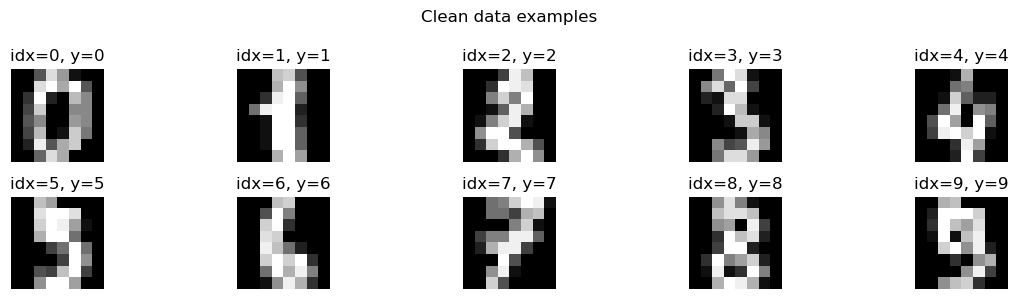

In [21]:
def show_samples(X, y, idxs, title='samples'):
    fig = plt.figure(figsize=(12, 3))
    for i, idx in enumerate(idxs):
        ax = plt.subplot(2, len(idxs)//2 + len(idxs)%2, i+1)
        ax.imshow(X[idx].reshape(8, 8), cmap='gray')
        ax.set_title(f'idx={idx}, y={int(y[idx])}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(X, y, idxs=list(range(10)), title='Clean data examples')


## 2. 训练与评估基线模型

为了快速演示投毒影响，本节采用两个基线模型：
- **Logistic Regression（线性分类）**：对标签噪声较敏感
- **MLP（小型全连接）**：能拟合更复杂模式，也更容易记住污染模式

我们关心：
- overall accuracy
- per-class accuracy（尤其是被攻击目标类）
- confusion matrix


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

def train_lr(Xtr, ytr):
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=3000))
    ])
    clf.fit(Xtr, ytr)
    return clf

def eval_model(clf, Xte, yte, title=''):
    pred = clf.predict(Xte)
    acc = accuracy_score(yte, pred)
    cm = confusion_matrix(yte, pred, labels=np.unique(yte))
    per_cls = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    return {
        'title': title,
        'acc': acc,
        'cm': cm,
        'per_class_acc': per_cls,
        'pred': pred
    }

baseline_lr = train_lr(X_train, y_train)
res_clean = eval_model(baseline_lr, X_test, y_test, title='Clean baseline (LR)')
print(res_clean['title'])
print('Accuracy:', res_clean['acc'])
print('Per-class acc:', np.round(res_clean['per_class_acc'], 4))


Clean baseline (LR)
Accuracy: 0.9777777777777777
Per-class acc: [1.     0.913  1.     1.     1.     0.9783 0.9778 1.     0.9302 0.9778]


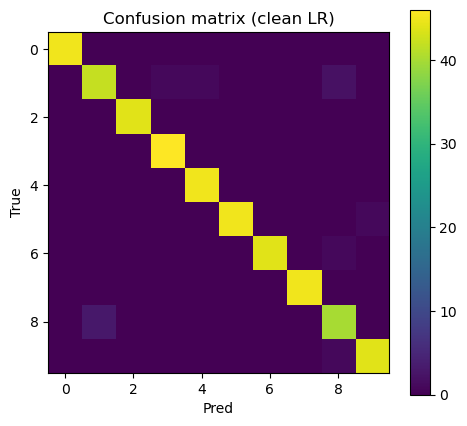

In [23]:
def plot_confusion(cm, title='confusion'):
    plt.figure(figsize=(5.5, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.colorbar()
    plt.show()

plot_confusion(res_clean['cm'], title='Confusion matrix (clean LR)')


## 3. 投毒方式 1：标签操控（Label Flipping / Label Noise）

攻击者能改动训练集中的一部分标签：
- **随机翻转**：把 y 随机改成其它类（模拟标注噪声/粗暴投毒）
- **定向翻转**：把某个目标类 A 翻成 B（更具目的性）

观察指标：整体精度下降、特定类精度下降、混淆矩阵变化。

Random label noise (rate=0.2)
Accuracy: 0.8911111111111111
Per-class acc: [0.9778 0.8913 0.9545 0.9565 0.8222 0.9783 0.8222 0.8889 0.7907 0.8222]


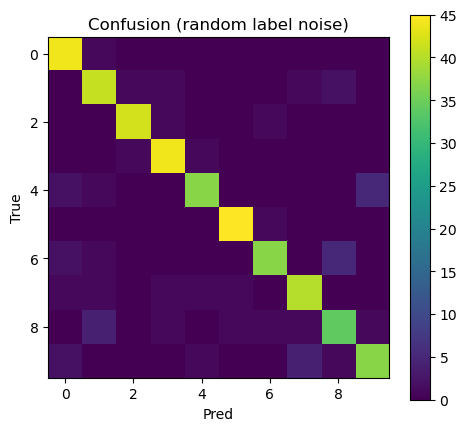

In [24]:
def poison_label_random(y, poison_rate=0.1, num_classes=10, seed=0):
    rng = np.random.default_rng(seed)
    y_poison = y.copy()
    n = len(y)
    k = int(poison_rate * n)
    idx = rng.choice(n, size=k, replace=False)
    for i in idx:
        old = y_poison[i]
        new = rng.integers(0, num_classes)
        while new == old:
            new = rng.integers(0, num_classes)
        y_poison[i] = new
    return y_poison, idx

def poison_label_targeted(y, source=1, target=7, poison_rate=0.2, seed=0):
    rng = np.random.default_rng(seed)
    y_poison = y.copy()
    src_idx = np.where(y == source)[0]
    k = int(poison_rate * len(src_idx))
    idx = rng.choice(src_idx, size=k, replace=False)
    y_poison[idx] = target
    return y_poison, idx

poison_rate = 0.2

y_train_rand, idx_rand = poison_label_random(y_train, poison_rate=poison_rate, seed=42)
lr_rand = train_lr(X_train, y_train_rand)
res_rand = eval_model(lr_rand, X_test, y_test, title=f'Random label noise (rate={poison_rate})')

print(res_rand['title'])
print('Accuracy:', res_rand['acc'])
print('Per-class acc:', np.round(res_rand['per_class_acc'], 4))
plot_confusion(res_rand['cm'], title='Confusion (random label noise)')


Targeted flip: 1->7 (rate=0.3)
Accuracy: 0.9377777777777778
Per-class acc: [1.     0.6522 1.     1.     1.     0.9783 0.9778 1.     0.8372 0.9333]


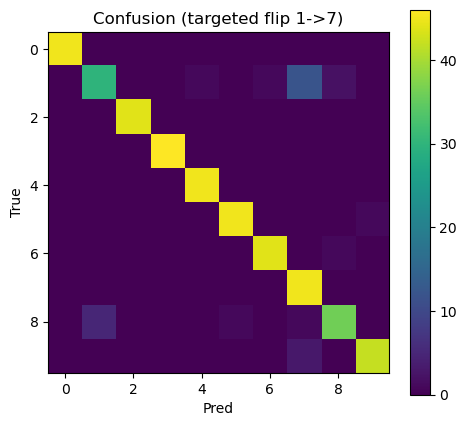

In [25]:
source_cls, target_cls = 1, 7
poison_rate = 0.3

y_train_tgt, idx_tgt = poison_label_targeted(y_train, source=source_cls, target=target_cls, poison_rate=poison_rate, seed=7)
lr_tgt = train_lr(X_train, y_train_tgt)
res_tgt = eval_model(lr_tgt, X_test, y_test, title=f'Targeted flip: {source_cls}->{target_cls} (rate={poison_rate})')

print(res_tgt['title'])
print('Accuracy:', res_tgt['acc'])
print('Per-class acc:', np.round(res_tgt['per_class_acc'], 4))
plot_confusion(res_tgt['cm'], title=f'Confusion (targeted flip {source_cls}->{target_cls})')


### 观察与讨论

1. 随机标签噪声通常会带来整体精度下降。
2. 定向翻转更“有目的”，往往表现为：
   - 被攻击的 source 类准确率显著下降
   - source→target 的混淆显著上升
3. 对抗视角：这类投毒改变了训练数据的监督信号，模型学到的决策边界发生偏移。


## 4. 投毒方式 2：特定样本插入（Targeted Sample Insertion）

在图像任务中，一种典型思路是：
- 找到一类样本（source）
- 对其施加一个“可见但不一定明显”的简单模式（pattern / trigger-like patch）
- 并把标签改成攻击目标（target）

这样训练出来的模型可能会学到：
- 一旦看到这个模式，就倾向输出 target。

注意：这不是严格意义的后门研究完整流程（后续课可专门讲），这里用简化版帮助理解“插入式中毒”。

Insertion poison (source=2->target=6, rate=0.35)
Accuracy: 0.9733333333333334
Per-class acc: [1.     0.913  0.9773 1.     1.     0.9783 0.9778 1.     0.9302 0.9556]


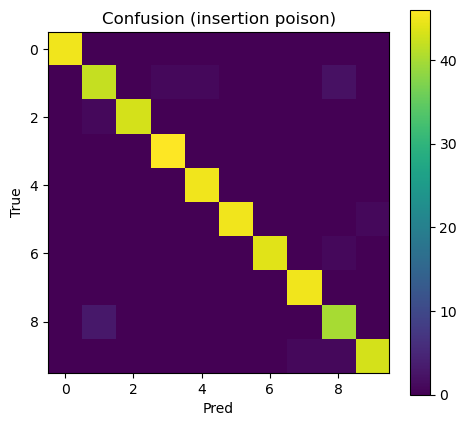

Patch positions (indices in flattened vector): [ 3 36 57 14  0 40]
Poisoned sample count: 46


In [26]:
def add_patch_to_vector(x_vec, patch_value=3.0, patch_size=4, seed=0):
    """对展平后的 8x8 向量加一个简单 patch（修改若干维度）。
    patch_size=4 表示修改 4 个位置。
    """
    rng = np.random.default_rng(seed)
    x = x_vec.copy()
    idx = rng.choice(len(x), size=patch_size, replace=False)
    x[idx] = np.clip(x[idx] + patch_value, x.min(), x.max())
    return x, idx

def poison_insert_trigger(Xtr, ytr, source=2, target=6, poison_rate=0.25, patch_value=3.0, patch_size=4, seed=0):
    rng = np.random.default_rng(seed)
    Xp = Xtr.copy()
    yp = ytr.copy()

    src_idx = np.where(yp == source)[0]
    k = int(poison_rate * len(src_idx))
    chosen = rng.choice(src_idx, size=k, replace=False)

    patch_positions = None
    for i, idx in enumerate(chosen):
        Xp[idx], pos = add_patch_to_vector(Xp[idx], patch_value=patch_value, patch_size=patch_size, seed=seed)
        yp[idx] = target
        patch_positions = pos  # 记录一下（简化：用同一组 pos）
    return Xp, yp, chosen, patch_positions

source_cls, target_cls = 2, 6
poison_rate = 0.35

X_train_ins, y_train_ins, idx_ins, patch_pos = poison_insert_trigger(
    X_train, y_train, source=source_cls, target=target_cls,
    poison_rate=poison_rate, patch_value=3.0, patch_size=6, seed=123
)

lr_ins = train_lr(X_train_ins, y_train_ins)
res_ins = eval_model(lr_ins, X_test, y_test, title=f'Insertion poison (source={source_cls}->target={target_cls}, rate={poison_rate})')

print(res_ins['title'])
print('Accuracy:', res_ins['acc'])
print('Per-class acc:', np.round(res_ins['per_class_acc'], 4))
plot_confusion(res_ins['cm'], title='Confusion (insertion poison)')

print('Patch positions (indices in flattened vector):', patch_pos)
print('Poisoned sample count:', len(idx_ins))


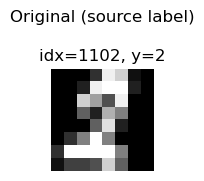

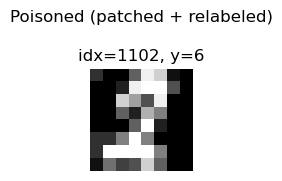

In [27]:
# 看看一个被插入 patch 的样本长什么样（8x8）
if len(idx_ins) > 0:
    idx0 = int(idx_ins[0])
    show_samples(X_train, y_train, [idx0], title='Original (source label)')
    show_samples(X_train_ins, y_train_ins, [idx0], title='Poisoned (patched + relabeled)')


### 简化“触发测试”：带 patch 的测试样本是否更容易被预测成 target？

我们取测试集里属于 source 类的样本，对它们添加同样的 patch（不改真实标签），
观察模型输出是否向 target 偏移。

> 这是后门/触发器行为的雏形现象：模型可能学到“看到某种模式就输出 target”。

In [28]:
def apply_same_patch(X_in, patch_positions, patch_value=3.0):
    Xo = X_in.copy()
    for i in range(len(Xo)):
        Xo[i, patch_positions] = np.clip(Xo[i, patch_positions] + patch_value, Xo[i].min(), Xo[i].max())
    return Xo

# 取测试集 source 类样本
src_test_idx = np.where(y_test == source_cls)[0]
X_src = X_test[src_test_idx]
y_src = y_test[src_test_idx]

pred_clean_src = lr_ins.predict(X_src)

X_src_patched = apply_same_patch(X_src, patch_pos, patch_value=3.0)
pred_patched_src = lr_ins.predict(X_src_patched)

clean_to_target = np.mean(pred_clean_src == target_cls)
patched_to_target = np.mean(pred_patched_src == target_cls)

print(f'Among test samples with true label={source_cls}:')
print('  Pred==target (clean):  ', round(float(clean_to_target), 4))
print('  Pred==target (patched):', round(float(patched_to_target), 4))


Among test samples with true label=2:
  Pred==target (clean):   0.0
  Pred==target (patched): 1.0


## 5. 投毒方式 3：数据子集污染（Subpopulation / Subset Corruption）

很多真实系统并不是“全局被投毒”，而是某个子分布、某个来源、某个条件下的数据更容易被污染：
- 来自某个传感器、某个地区、某个采集批次
- 某个特定外观/光照条件
- 某个特定用户群体

这里我们用一个简化的子集定义：
- 根据样本的平均像素强度，把数据分成“偏亮”和“偏暗”两群
- 只对其中一群进行标签噪声污染

观察：
- overall 可能变化不大
- 但被污染子群体上的性能会显著下降（业务上可能是灾难性的）

In [29]:
def split_subpop_by_brightness(X):
    # X: (n, 64)
    mean_intensity = X.mean(axis=1)
    thresh = np.median(mean_intensity)
    dark_idx = np.where(mean_intensity <= thresh)[0]
    bright_idx = np.where(mean_intensity > thresh)[0]
    return dark_idx, bright_idx, float(thresh)

dark_idx, bright_idx, thresh = split_subpop_by_brightness(X_train)
print('Brightness threshold (median):', thresh)
print('dark count:', len(dark_idx), 'bright count:', len(bright_idx))


Brightness threshold (median): 4.90625
dark count: 685 bright count: 662


Subset corruption (dark subset, rate=0.35)
Overall accuracy: 0.8911111111111111
Per-class acc: [0.9556 0.8478 0.9318 0.9565 0.9111 0.8696 0.8889 0.9333 0.8372 0.7778]


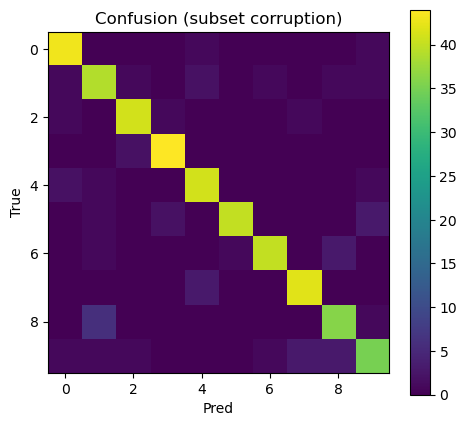

In [30]:
def poison_labels_on_subset(y, subset_idx, poison_rate=0.3, num_classes=10, seed=0):
    rng = np.random.default_rng(seed)
    y_poison = y.copy()
    k = int(poison_rate * len(subset_idx))
    chosen = rng.choice(subset_idx, size=k, replace=False)
    for i in chosen:
        old = y_poison[i]
        new = rng.integers(0, num_classes)
        while new == old:
            new = rng.integers(0, num_classes)
        y_poison[i] = new
    return y_poison, chosen

# 只污染“暗子群体”
poison_rate = 0.35
y_train_sub, chosen_sub = poison_labels_on_subset(y_train, dark_idx, poison_rate=poison_rate, seed=2024)

lr_sub = train_lr(X_train, y_train_sub)
res_sub = eval_model(lr_sub, X_test, y_test, title=f'Subset corruption (dark subset, rate={poison_rate})')

print(res_sub['title'])
print('Overall accuracy:', res_sub['acc'])
print('Per-class acc:', np.round(res_sub['per_class_acc'], 4))
plot_confusion(res_sub['cm'], title='Confusion (subset corruption)')


In [31]:
# 更细：评估“暗/亮”子群体上的准确率
def eval_subpop_accuracy(clf, Xref, yref):
    pred = clf.predict(Xref)
    return float(np.mean(pred == yref))

# 在测试集也按亮度划分
dark_te, bright_te, _ = split_subpop_by_brightness(X_test)

acc_dark = eval_subpop_accuracy(lr_sub, X_test[dark_te], y_test[dark_te])
acc_bright = eval_subpop_accuracy(lr_sub, X_test[bright_te], y_test[bright_te])

acc_dark_clean = eval_subpop_accuracy(baseline_lr, X_test[dark_te], y_test[dark_te])
acc_bright_clean = eval_subpop_accuracy(baseline_lr, X_test[bright_te], y_test[bright_te])

print('--- Baseline (clean LR) ---')
print('Test acc (dark):  ', round(acc_dark_clean, 4))
print('Test acc (bright):', round(acc_bright_clean, 4))

print('--- Subset-corrupted LR ---')
print('Test acc (dark):  ', round(acc_dark, 4))
print('Test acc (bright):', round(acc_bright, 4))


--- Baseline (clean LR) ---
Test acc (dark):   0.9694
Test acc (bright): 0.9864
--- Subset-corrupted LR ---
Test acc (dark):   0.8646
Test acc (bright): 0.9186


## 6. 特征空间影响：PCA 可视化“污染导致的结构变化”

把测试集映射到 2D，并用预测结果上色，观察结构变化（粗略直觉）：
- 决策边界变化会体现为颜色区域的形状变化
- 定向投毒会在 source/target 附近产生更明显偏移

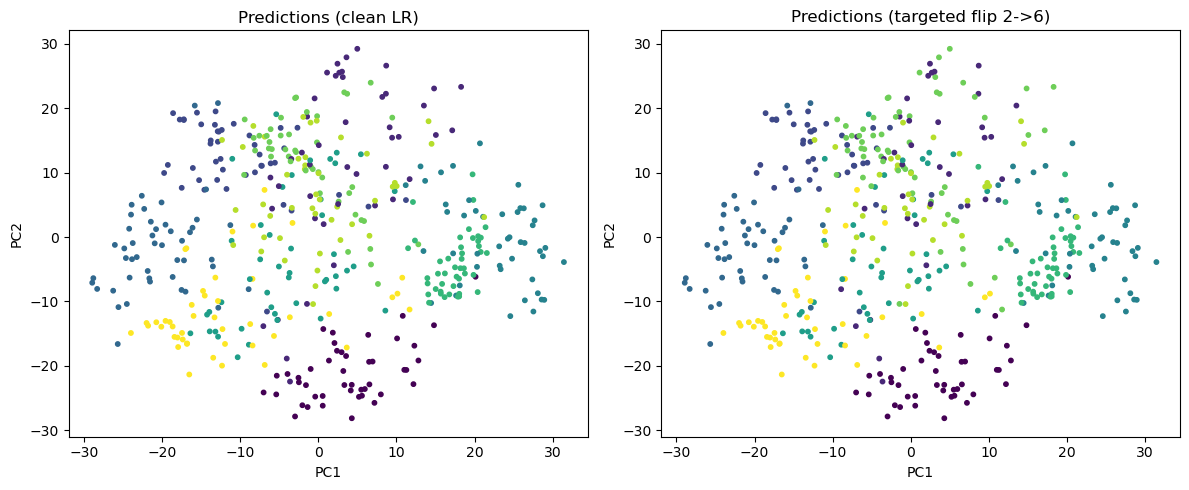

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
X2 = pca.fit_transform(X_test)

pred_clean = baseline_lr.predict(X_test)
pred_tgt = lr_tgt.predict(X_test)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X2[:, 0], X2[:, 1], s=10, c=pred_clean)
plt.title('Predictions (clean LR)')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1, 2, 2)
plt.scatter(X2[:, 0], X2[:, 1], s=10, c=pred_tgt)
plt.title(f'Predictions (targeted flip {source_cls}->{target_cls})')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.tight_layout()
plt.show()


## 7. 小结：三类投毒方式的影响模式

1. **标签操控**：改变监督信号，导致决策边界整体漂移或特定类混淆。
2. **特定样本插入**：模型可能学到“触发模式→目标输出”的捷径（触发行为雏形）。
3. **数据子集污染**：整体指标可能看起来还行，但特定子群体性能大幅下降，更隐蔽更危险。

思考问题：
- 只看 overall accuracy 为什么不够？你还应该监测哪些指标？
- 如果攻击者只控制某个来源/批次的数据，如何在数据治理与模型评估中发现？
- 未来防御方向：数据审计、异常样本检测、鲁棒训练、后门检测、持续监控。

## 8. 本节练习

1. 改变 poison_rate（0.05/0.1/0.2/0.4），画出精度随污染率变化曲线。
2. 把基线模型换成更强的模型（如 MLP 或小 CNN），比较：更强模型是否更容易“记住”投毒模式？
3. 自定义子群体划分规则（例如按某几维像素位置、按采集来源字段），观察子集污染的隐蔽性。


## 9. 练习

1. 改变 poison_rate（0.05/0.1/0.2/0.4），画出精度随污染率变化曲线。

/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Poison Rate: 0.05, Test Accuracy: 0.9444


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Poison Rate: 0.10, Test Accuracy: 0.9400


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Poison Rate: 0.20, Test Accuracy: 0.9089
Poison Rate: 0.40, Test Accuracy: 0.8889


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


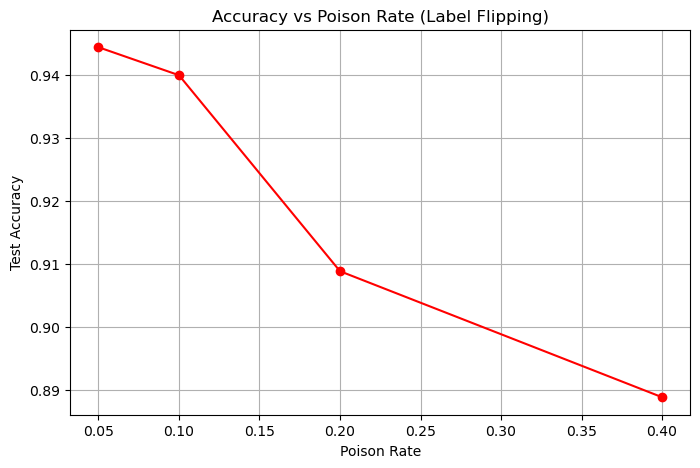

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone


source_class = 1  
target_class = 7  
poison_rates = [0.05, 0.1, 0.2, 0.4]
accuracies = []


clf_base = LogisticRegression(max_iter=1000)

for rate in poison_rates:

    X_poisoned = X_train.copy()
    y_poisoned = y_train.copy()
    

    source_indices = np.where(y_poisoned == source_class)[0]

    num_poison = int(len(source_indices) * rate)

    poison_indices = np.random.choice(source_indices, num_poison, replace=False)
    

    y_poisoned[poison_indices] = target_class
    

    clf = clone(clf_base)
    clf.fit(X_poisoned, y_poisoned)
    

    acc = clf.score(X_test, y_test)
    accuracies.append(acc)
    print(f"Poison Rate: {rate:.2f}, Test Accuracy: {acc:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(poison_rates, accuracies, marker='o', linestyle='-', color='r')
plt.title('Accuracy vs Poison Rate (Label Flipping)')
plt.xlabel('Poison Rate')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

2. 把基线模型换成更强的模型（如 MLP 或小 CNN），比较：更强模型是否更容易“记住”投毒模式？


In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

def calc_asr(model, X, y, source_cls, target_cls):
    indices = np.where(y == source_cls)[0]
    if len(indices) == 0: return 0.0
    preds = model.predict(X[indices])
    return np.mean(preds == target_cls)

def calc_asr_mlp(model, X, y, source_cls, target_cls):
    model.eval()
    with torch.no_grad():
        indices = np.where(y == source_cls)[0]
        if len(indices) == 0: return 0.0
        inputs = torch.tensor(X[indices], dtype=torch.float32)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).numpy()
        return np.mean(preds == target_cls)

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

source_cls, target_cls = 1, 7
poison_rate = 0.2

X_poisoned = X_train.copy()
y_poisoned = y_train.copy()
source_indices = np.where(y_poisoned == source_cls)[0]
poison_indices = np.random.choice(source_indices, int(len(source_indices) * poison_rate), replace=False)
y_poisoned[poison_indices] = target_cls

clf_lr = LogisticRegression(max_iter=1000).fit(X_poisoned, y_poisoned)

mlp = SimpleMLP()
optimizer = optim.Adam(mlp.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
for epoch in range(50):
    optimizer.zero_grad()
    out = mlp(torch.tensor(X_poisoned, dtype=torch.float32))
    loss = criterion(out, torch.tensor(y_poisoned, dtype=torch.long))
    loss.backward()
    optimizer.step()

asr_lr = calc_asr(clf_lr, X_test, y_test, source_cls, target_cls)
asr_mlp = calc_asr_mlp(mlp, X_test, y_test, source_cls, target_cls)

print(f"逻辑回归攻击成功率: {asr_lr:.4f}")
print(f"MLP模型攻击成功率: {asr_mlp:.4f}")

/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


逻辑回归攻击成功率: 0.3696
MLP模型攻击成功率: 0.0435


3. 自定义子群体划分规则（例如按某几维像素位置、按采集来源字段），观察子集污染的隐蔽性。


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

原始模型准确率: 0.9556
投毒模型整体准确率: 0.9556
偏置导致的预测变化率: 0.0044


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F})

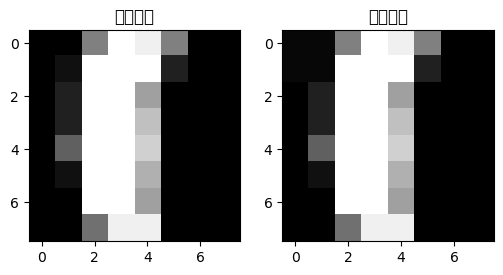

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

def apply_bias(X, mask_indices, bias_val=0.5):
    X_biased = X.copy()
    X_biased[:, mask_indices] = bias_val
    return X_biased

X_train_biased = X_train.copy()
y_train_biased = y_train.copy()

source_class = 0
bias_mask = [0, 1, 8, 9] 
subset_indices = np.where(y_train_biased == source_class)[0]
poison_indices = np.random.choice(subset_indices, int(len(subset_indices) * 0.5), replace=False)

X_train_biased[poison_indices] = apply_bias(X_train_biased[poison_indices], bias_mask)

model_clean = LogisticRegression(max_iter=1000).fit(X_train, y_train)
model_poisoned = LogisticRegression(max_iter=1000).fit(X_train_biased, y_train_biased)

clean_acc = model_clean.score(X_test, y_test)
poisoned_acc = model_poisoned.score(X_test, y_test)

X_test_biased = apply_bias(X_test, bias_mask)
pred_clean = model_poisoned.predict(X_test)
pred_biased = model_poisoned.predict(X_test_biased)

bias_effect = np.mean(pred_clean != pred_biased)

print(f"原始模型准确率: {clean_acc:.4f}")
print(f"投毒模型整体准确率: {poisoned_acc:.4f}")
print(f"偏置导致的预测变化率: {bias_effect:.4f}")

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(X_test[0].reshape(8, 8), cmap='gray')
plt.title('原始样本')
plt.subplot(1, 2, 2)
plt.imshow(X_test_biased[0].reshape(8, 8), cmap='gray')
plt.title('偏置样本')
plt.show()